In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np

Regions used to extract the signal can be defined by a “hard” parcellation. For instance, the nilearn.datasets has functions to download atlases forming reference parcellation, e.g., fetch_atlas_craddock_2012, fetch_atlas_harvard_oxford, fetch_atlas_yeo_2011.

In [3]:
frmi_files = os.path.join(
    '..', '..',
    'datasets', 'hcp-openaccess', 'rfMRI_REST1_LR_hp2000_clean.nii.gz'
)

# Anatomical atlas

In [4]:
from nilearn import datasets
dataset = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
atlas_filename = dataset.maps
labels = dataset.labels

/usr/local/anaconda3/envs/neuro-dynamic-covariance/lib/python3.7/site-packages/nilearn/datasets/__init__.py:90: FutureWarning: Fetchers from the nilearn.datasets module will be updated in version 0.9 to return python strings instead of bytes and Pandas dataframes instead of Numpy arrays.
  "Numpy arrays.", FutureWarning)


In [5]:
atlas_filename

'/Users/onnokampman/nilearn_data/fsl/data/atlases/HarvardOxford/HarvardOxford-cort-maxprob-thr25-2mm.nii.gz'

In [6]:
'Found %d regions of interest.' % len(labels)

'Found 49 regions of interest.'

In [7]:
labels

['Background',
 'Frontal Pole',
 'Insular Cortex',
 'Superior Frontal Gyrus',
 'Middle Frontal Gyrus',
 'Inferior Frontal Gyrus, pars triangularis',
 'Inferior Frontal Gyrus, pars opercularis',
 'Precentral Gyrus',
 'Temporal Pole',
 'Superior Temporal Gyrus, anterior division',
 'Superior Temporal Gyrus, posterior division',
 'Middle Temporal Gyrus, anterior division',
 'Middle Temporal Gyrus, posterior division',
 'Middle Temporal Gyrus, temporooccipital part',
 'Inferior Temporal Gyrus, anterior division',
 'Inferior Temporal Gyrus, posterior division',
 'Inferior Temporal Gyrus, temporooccipital part',
 'Postcentral Gyrus',
 'Superior Parietal Lobule',
 'Supramarginal Gyrus, anterior division',
 'Supramarginal Gyrus, posterior division',
 'Angular Gyrus',
 'Lateral Occipital Cortex, superior division',
 'Lateral Occipital Cortex, inferior division',
 'Intracalcarine Cortex',
 'Frontal Medial Cortex',
 'Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)',
 'Subcallo

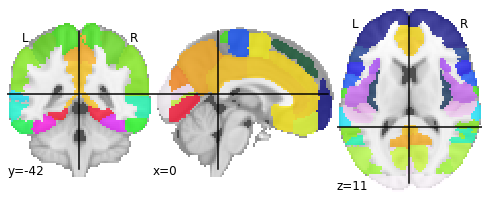

In [8]:
from nilearn import plotting
plotting.plot_roi(atlas_filename)

In [12]:
from nilearn import image
rsn = image.load_img(frmi_files)
rsn.shape

(91, 109, 91, 1200)

In [13]:
first_rsn = image.index_img(rsn, 0)
first_rsn.shape

(91, 109, 91)

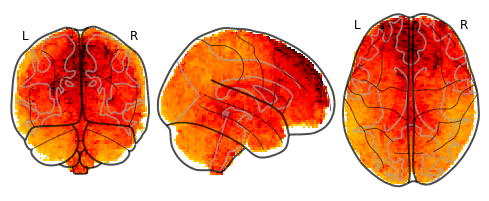

In [14]:
plotting.plot_glass_brain(first_rsn)

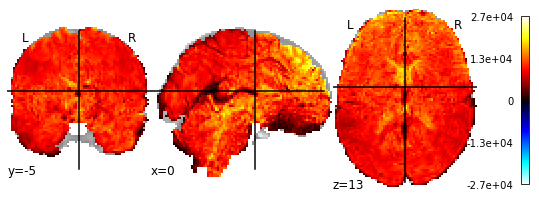

In [15]:
plotting.plot_stat_map(first_rsn)

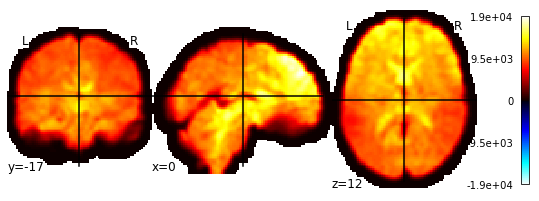

In [16]:
smoothed_img = image.smooth_img(first_rsn, fwhm=5)
plotting.plot_stat_map(smoothed_img)

# Extract signals on a parcellation

In [5]:
from nilearn.input_data import NiftiLabelsMasker
masker = NiftiLabelsMasker(labels_img=atlas_filename, standardize=True)

In [6]:
masker

NiftiLabelsMasker(labels_img='/Users/onnokampman/nilearn_data/fsl/data/atlases/HarvardOxford/HarvardOxford-cort-maxprob-thr25-2mm.nii.gz',
                  standardize=True)

In [10]:
time_series = masker.fit_transform(
    frmi_files, 
    confounds=None
)

In [11]:
type(time_series)

numpy.ndarray

In [12]:
time_series.shape

(1200, 48)

Text(0.5, 1.0, 'Time series region Frontal Pole')

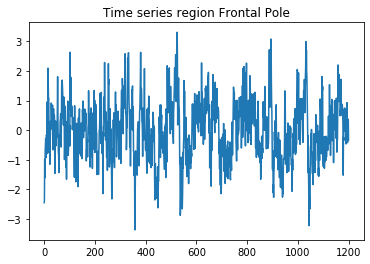

In [41]:
plt.plot(time_series[:, 1])
plt.title('Time series region %s' % labels[1])

In [33]:
from nilearn.connectome import ConnectivityMeasure

In [34]:
cn = ConnectivityMeasure()

In [35]:
corr_matrix = cn.fit_transform([time_series])
corr_matrix.shape

(1, 48, 48)

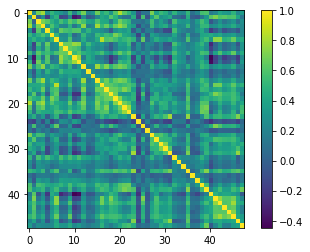

In [39]:
plt.imshow(corr_matrix[0, :, :])
plt.colorbar()
# plt.xlabel(labels)

In [25]:
corr_matrix = np.corrcoef(time_series.T)
corr_matrix.shape

(48, 48)

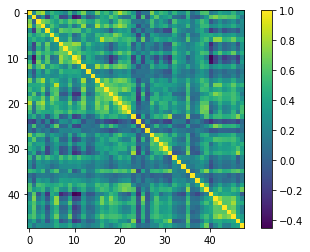

In [26]:
plt.imshow(corr_matrix)
plt.colorbar()

In [27]:
plotting.plot_connectome(corr_matrix)

TypeError: plot_connectome() missing 1 required positional argument: 'node_coords'

# Functional ICA-based atlas